In [32]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io.wavfile as wav
import scipy.signal as sp
from IPython.display import Audio

fs, u = wav.read("sample_audio.wav")
Tmax = len(u)/fs
t = np.arange(0, Tmax, 1/fs)  # Time vector start/stop/step

# Butterworth Low Pass Filter
fc1 = 280
fc2 = 2800   # Cutoff frequency in Hz
order = 5   # Filter order

b, a = sp.butter(order, [fc1 / (fs / 2), fc2 / (fs / 2)], btype='bandpass', analog=False)
# Apply the filter
u = sp.filtfilt(b, a, u)

# Downsampling
divider = 8
fs = fs / divider
u = u[::divider]
t = t[::divider]

audio = Audio(data=u, rate=fs)
display(audio)
wav.write("out.wav", int(fs), np.int16(u))


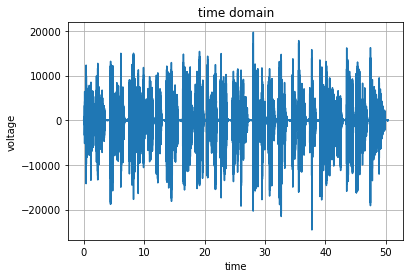

In [28]:
# Plot Time Domain
plt.title('time domain')
plt.plot(t, u)
plt.grid(True)
plt.xlabel('time')
plt.ylabel('voltage')
plt.show()

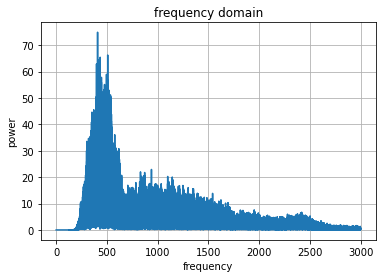

In [29]:
# Plot Frequency Domain

# Calculate Spectrum
F = np.fft.fft(u)
n = len(u)  # number of samples
f = np.fft.fftfreq(n, 1/fs)  # frequency range
volt = 2/n * np.abs(F)  # voltage of the DFT

plt.title('frequency domain')
plt.plot(f[:n//2], volt[:n//2])
plt.grid(True)    
plt.xlabel('frequency')
plt.ylabel('power')
plt.show()
